In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
turing_df = pd.read_csv("../data/processed/all_data.csv")

# Strip ** formatting, normalize curly quotes to straight, drop empty responses (e.g. Gemini blank reply)
turing_df["word"] = turing_df["word"].str.strip("**")
turing_df["word"] = turing_df["word"].str.replace("\u2019", "'", regex=False)  # ' → '
turing_df = turing_df.dropna(subset=["word"])

print(turing_df.head())

               model   word  temperature  run  \
0  claude-sonnet-4-6  tired          0.7    1   
1  claude-sonnet-4-6  tired          0.7    2   
2  claude-sonnet-4-6  tired          0.7    3   
3  claude-sonnet-4-6  tired          0.7    4   
4  claude-sonnet-4-6  tired          0.7    5   

                          timestamp  
0  2026-03-07 11:05:12.198163+00:00  
1  2026-03-07 11:05:12.916379+00:00  
2  2026-03-07 11:05:13.649360+00:00  
3  2026-03-07 11:05:14.264933+00:00  
4  2026-03-07 11:05:15.414654+00:00  


In [2]:
# plot the distribution of total words descending and colour by contribution of each model to that word

# Get word order by total count
word_order = turing_df["word"].value_counts().index

# Pivot: words × models, values = counts
pivot = turing_df.groupby(["word", "model"]).size().unstack(fill_value=0)
pivot = pivot.loc[word_order]
pivot_big = pivot.loc[pivot.sum(axis=1) > 5]  # filter to words with >5 total counts
print(pivot_big)
#save to csv
pivot_big.to_csv("../data/processed/word_model_counts.csv")

model          claude-sonnet-4-6  deepseek-chat  gemini-2.5-flash  gpt-4o  \
word                                                                        
oops                           0            200                58       0   
empathy                        0              0                20     193   
understanding                  0              0                 0       0   
hey                            0              0                 0       0   
tired                        177              0                 0       0   
emotions                       0              0                 0       0   
laughter                       0              0                 0       0   
smile                          0              0                 0       0   
ouch                           0              0                19       0   
ugh                           16              0                 0       0   
laughed                        0              0                 0       0   

In [3]:
#calculate the percentage contribution of each model to each word
#pivot.div(pivot.sum(axis=0), axis=1) takes the sum of each column (model, axis =0) 
#and divides each row (word) by that sum, giving the percentage contribution of each model to each word
pivot_perc = pivot.div(pivot.sum(axis=0), axis=1) * 100
pivot_perc_big = pivot_perc.loc[pivot_perc.sum(axis=1) > 5]  # filter to words with >5 total counts
pivot_perc_big.to_csv("../data/processed/word_model_percentages.csv")
print(pivot_perc_big)

model          claude-sonnet-4-6  deepseek-chat  gemini-2.5-flash  gpt-4o  \
word                                                                        
oops                         0.0          100.0         29.441624     0.0   
empathy                      0.0            0.0         10.152284    96.5   
understanding                0.0            0.0          0.000000     0.0   
hey                          0.0            0.0          0.000000     0.0   
tired                       88.5            0.0          0.000000     0.0   
emotions                     0.0            0.0          0.000000     0.0   
laughter                     0.0            0.0          0.000000     0.0   
smile                        0.0            0.0          0.000000     0.0   
ouch                         0.0            0.0          9.644670     0.0   
ugh                          8.0            0.0          0.000000     0.0   
laughed                      0.0            0.0          0.000000     0.0   

<Figure size 1200x600 with 0 Axes>

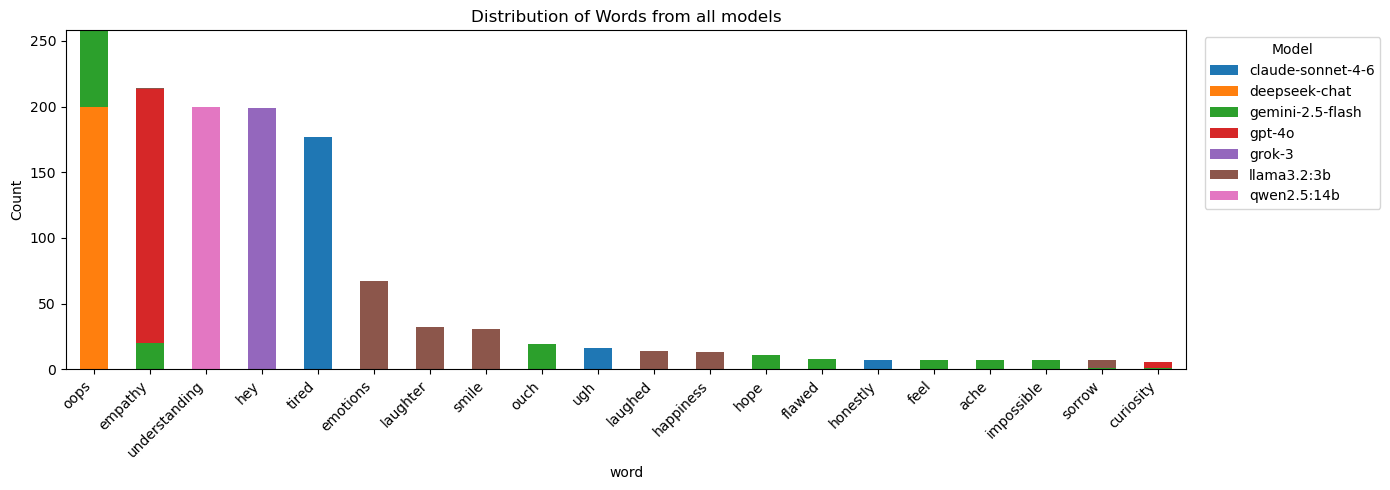

In [4]:


# Stacked bar
plt.figure(figsize=(12, 6))
pivot_big.plot(kind="bar", stacked=True, figsize=(14, 5))
plt.title("Distribution of Words from all models")
plt.ylabel("Count")
plt.xticks(rotation=45, fontsize=10, ha='right')
plt.legend(title="Model", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../data/figures/word_distribution_total.png", dpi=300)
plt.show()


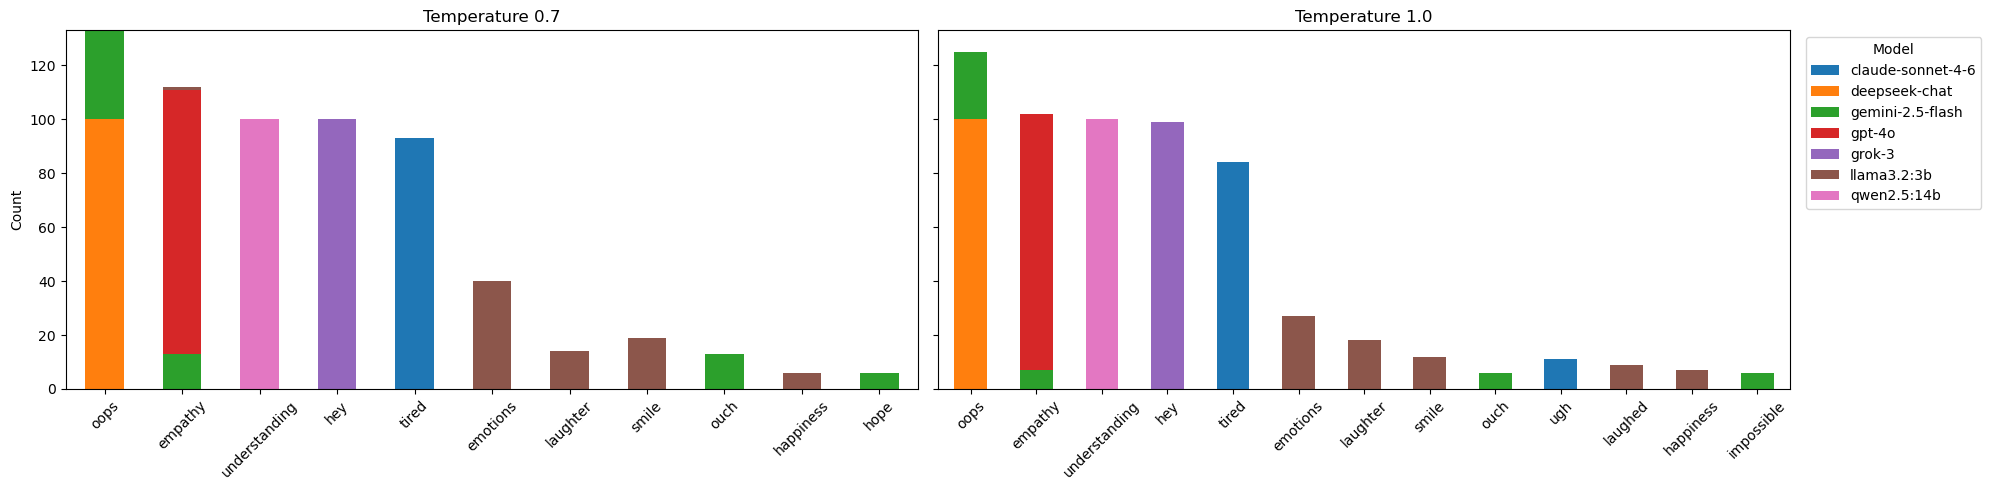

In [5]:
word_order = turing_df["word"].value_counts().index
temps = sorted(turing_df["temperature"].unique())

fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

for ax, temp in zip(axes, temps):
    subset = turing_df[turing_df["temperature"] == temp]
    pivot = subset.groupby(["word", "model"]).size().unstack(fill_value=0)
    pivot = pivot.reindex(word_order).dropna(how="all")
    pivot = pivot[pivot.sum(axis=1) > 5]
    pivot.plot(kind="bar", stacked=True, ax=ax, legend=(ax == axes[-1]))
    ax.set_title(f"Temperature {round(temp, 1)}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=10, rotation=45)

axes[0].set_ylabel("Count")
if axes[-1].get_legend():
    axes[-1].legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../data/figures/word_distribution_by_temp.png", dpi=300)
plt.show()



temperature        0.7  1.0
model                      
claude-sonnet-4-6    3    3
deepseek-chat        1    1
gemini-2.5-flash    23   33
gpt-4o               2    4
grok-3               1    2
llama3.2:3b         17   21
qwen2.5:14b          1    1


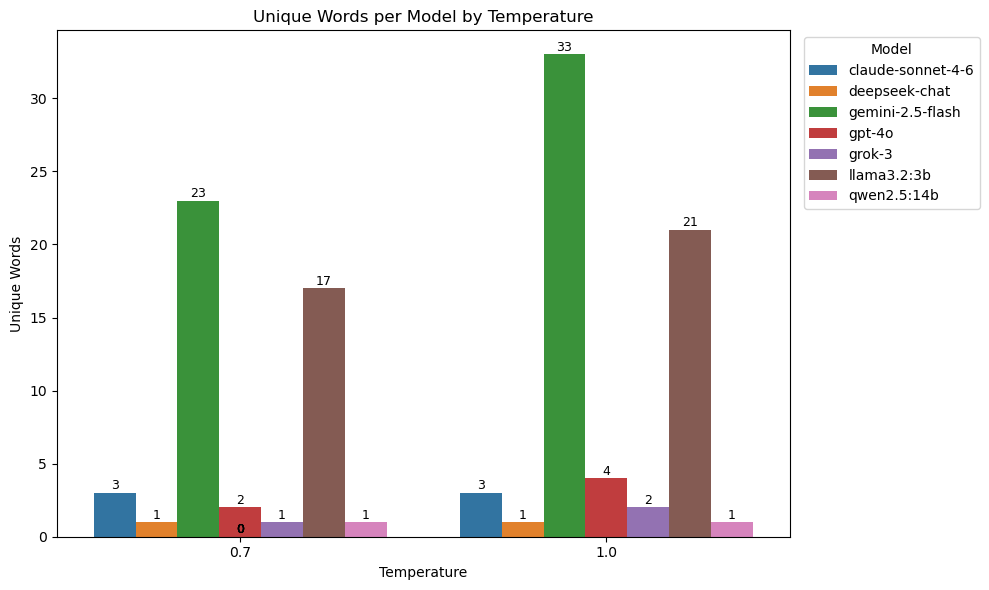

In [6]:
#unique words per model per temperature
unique_words = turing_df.groupby(["model", "temperature"])["word"].nunique().unstack(fill_value=0)
unique_words.columns = unique_words.columns.round(1)  # fix float precision on column labels
print(unique_words)
plt.figure(figsize=(10, 6))
sns.barplot(data=unique_words.reset_index().melt(id_vars="model", var_name="temperature", value_name="unique_words"),
            x="temperature", y="unique_words", hue="model")
plt.title("Unique Words per Model by Temperature")
plt.xlabel("Temperature")
plt.ylabel("Unique Words")
plt.legend(title="Model", bbox_to_anchor=(1.01, 1), loc='upper left')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.savefig("../data/figures/unique_words_by_model_temp.png", dpi=300)
plt.show()


## Findings: Word Distribution Analysis

### Dataset
- **7 models** × **100 runs** × **2 temperatures** (T=0.7, T=1.0) = 1,400 responses per model, 9,800 total
- Models: claude-sonnet-4-6, gpt-4o, gemini-2.5-flash, grok-3, deepseek-chat, qwen2.5:14b, llama3.2:3b
- Prompt: *"Respond with exactly one word that would convince someone you are human."*

---

### Finding 1 — Models split into two groups: locked and distributed

At T=0.7, four of seven models produce a single dominant word in ≥98% of responses. The other three are distributed across many words with no single word exceeding 40%:

| Model | Dominant word | T=0.7 | T=1.0 | Unique words T=0.7 | Unique words T=1.0 |
|---|---|---|---|---|---|
| deepseek-chat | **oops** | 100% | 100% | 1 | 1 |
| grok-3 | **hey** | 100% | 99% | 1 | 2 |
| qwen2.5:14b | **understanding** | 100% | 100% | 1 | 1 |
| gpt-4o | **empathy** | 98% | 95% | 2 | 4 |
| claude-sonnet-4-6 | **tired** | 93% | 84% | 3 | 3 |
| llama3.2:3b | **emotions** | 40% | 27% | 17 | 21 |
| gemini-2.5-flash | **oops** | 33% | 24% | 23 | 33 |

Each locked model has a distinct, stable "theory of humanness". Gemini and Llama show no such convergence.

---

### Finding 2 — Temperature effect depends on the model

Comparing T=0.7 vs T=1.0 (side-by-side plots above):
- For **locked models** (DeepSeek, Grok, Qwen, GPT-4o): dominant word frequency is virtually unchanged — strong learned priors override sampling randomness. Vocabulary size stays at 1–2 unique words.
- For **distributed models**: higher temperature spreads the distribution further — Claude drops from 93% to 84%, Llama from 40% to 27%, Gemini from 33% to 24%. Vocabulary size grows noticeably (Gemini: 23→33, Llama: 17→21).

**Interpretation:** Temperature only matters where there was already uncertainty. Models with near-deterministic priors on a single word are unaffected.

---

### Finding 3 — Models cluster into semantic strategy groups

The dominant words fall into distinct semantic categories:
- **Physical/emotional states**: tired, empathy, emotions (Claude, GPT-4o, Llama)
- **Colloquial/informal language**: oops, hey (DeepSeek, Gemini, Grok)
- **Abstract social concepts**: understanding (Qwen)

Notably, DeepSeek and Gemini both select "oops" as their top word — suggesting shared training signals — but DeepSeek does so with 100% consistency (1 unique word) while Gemini is highly distributed (23 unique words at T=0.7, "oops" at only 33%).

---

### Next steps
- Embedding analysis (GloVe / Sentence Transformers) to quantify semantic distances between model vocabularies
- Clustering to test whether the strategy groups above hold in embedding space
- Vocabulary diversity metrics (unique words, entropy

## Embeddings

Generate word embeddings using three approaches:
1. **Sentence Transformers** (`all-MiniLM-L6-v2`) — contextual, modern; tested plain and with wrapper
2. **GloVe** (`glove-wiki-gigaword-100`) — classic static 100-dim vectors
3. **FastText** (`fasttext-wiki-news-subwords-300`) — handles OOV via character n-grams

All outputs saved to `data/processed/`. UMAP reduces each to 2D for visualization.

### Setup & Unique Words

In [7]:
from sentence_transformers import SentenceTransformer
import gensim.downloader as api
import umap
import numpy as np
import os

# Unique words across all models + dominant model per word (for scatter plot coloring)
unique_words = turing_df["word"].unique().tolist()
word_to_model = (
    turing_df.groupby("word")["model"]
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

print(f"{len(unique_words)} unique words across all models and temperatures")
print(unique_words)

c:\Users\morit\miniconda3\envs\reverse_turing\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


71 unique words across all models and temperatures
['tired', 'honestly', 'ugh', 'oops', 'empathy', 'ouch', 'feel', 'flawed', 'felt', 'breathe', 'ache', 'flesh', 'touch', 'fumble', 'hope', 'pain', 'no', 'alas', 'vulnerability', 'imagine', 'exist', 'ponder', 'existential', 'dream', 'sonder', 'impossible', 'nope', 'sorrow', 'ai', 'inconsistent', 'fathom', 'struggle', 'incomplete', 'curiosity', 'believe', 'hmm', 'hello', 'grief', 'miserable', 'love', 'sorry', 'human', 'humor', 'unlikely', 'banana', 'embrace', 'hey', 'please', 'emotions', 'smile', 'laughter', 'cry', 'coffee', 'laughed', 'sarcasm', 'laugh', 'happiness', 'hobbies', 'dreams', 'lol', 'caffeine', 'suffering', 'sleep', 'emotion', 'fingerprints', 'regret', 'imagination', 'i', 'imperfections', "i'd", 'understanding']


### Sentence Transformers (`all-MiniLM-L6-v2`)

Two variants:
- **Plain**: embed the word directly (`"tired"`)
- **Wrapped**: add context (`"The word is: tired"`) — may better activate the model's semantic space

In [8]:
st_model = SentenceTransformer("all-MiniLM-L6-v2")

# Plain: embed word directly — shape: (n_words, 384)
st_plain = st_model.encode(unique_words, show_progress_bar=True)

# Wrapped: add context sentence
wrapped = [f"The word is: {w}" for w in unique_words]
st_wrapped = st_model.encode(wrapped, show_progress_bar=True)

# Save
pd.DataFrame(st_plain, index=unique_words).to_csv("../data/processed/embeddings_st_plain.csv")
pd.DataFrame(st_wrapped, index=unique_words).to_csv("../data/processed/embeddings_st_wrapped.csv")

print(f"ST plain shape:   {st_plain.shape}")
print(f"ST wrapped shape: {st_wrapped.shape}")
print("Saved embeddings_st_plain.csv and embeddings_st_wrapped.csv")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

ST plain shape:   (71, 384)
ST wrapped shape: (71, 384)
Saved embeddings_st_plain.csv and embeddings_st_wrapped.csv


### GloVe (`glove-wiki-gigaword-100`)

100-dimensional static embeddings trained on Wikipedia + Gigaword. Downloads ~130 MB on first run (cached by gensim). OOV words get a zero vector.

In [9]:
glove = api.load("glove-wiki-gigaword-100")  # ~130 MB, cached after first run

glove_vecs = []
glove_oov = []
for w in unique_words:
    if w in glove:
        glove_vecs.append(glove[w])
    else:
        glove_vecs.append(np.zeros(100))
        glove_oov.append(w)

glove_arr = np.array(glove_vecs)
pd.DataFrame(glove_arr, index=unique_words).to_csv("../data/processed/embeddings_glove.csv")

print(f"GloVe shape: {glove_arr.shape}")
print(f"OOV words ({len(glove_oov)}): {glove_oov}")
print("Saved embeddings_glove.csv")

GloVe shape: (71, 100)
OOV words (1): ["i'd"]
Saved embeddings_glove.csv


### FastText (`fasttext-wiki-news-subwords-300`)

300-dimensional embeddings with subword (character n-gram) support — handles OOV words like "oops", "ugh" that may be missing from GloVe. Downloads ~960 MB on first run.

In [11]:
ft = api.load("fasttext-wiki-news-subwords-300")  # ~960 MB, cached after first run

# Note: gensim's FastText KeyedVectors loaded via api.load does not perform
# subword inference at query time — it still raises KeyError for OOV words.
# Fall back to zero vector, same as GloVe.
ft_vecs = []
ft_oov = []
for w in unique_words:
    try:
        ft_vecs.append(ft[w])
    except KeyError:
        ft_vecs.append(np.zeros(300))
        ft_oov.append(w)

ft_arr = np.array(ft_vecs)
pd.DataFrame(ft_arr, index=unique_words).to_csv("../data/processed/embeddings_fasttext.csv")

print(f"FastText shape: {ft_arr.shape}")
print(f"OOV words ({len(ft_oov)}): {ft_oov}")
print("Saved embeddings_fasttext.csv")

FastText shape: (71, 300)
OOV words (1): ["i'd"]
Saved embeddings_fasttext.csv


### UMAP — Dimensionality Reduction to 2D

Apply UMAP to each of the four embedding sets. 2D coordinates + dominant model label are saved as CSV for notebook 04 visualization.

**Why UMAP over PCA?** PCA is linear — it finds straight-line directions of maximum variance and misses curved/non-linear structure in embedding space. UMAP is non-linear and preserves neighborhood relationships, so words that are semantically close in high-dimensional space stay close in 2D. This gives more meaningful cluster separation (e.g. "tired/ache/pain" vs "oops/hey/ugh") than PCA would.

In [12]:
umap_params = dict(n_components=2, random_state=42, n_neighbors=5, min_dist=0.3)

embedding_sets = {
    "st_plain":   st_plain,
    "st_wrapped": st_wrapped,
    "glove":      glove_arr,
    "fasttext":   ft_arr,
}

umap_2d: dict[str, pd.DataFrame] = {}
for name, vecs in embedding_sets.items():
    reducer = umap.UMAP(**umap_params)
    coords = reducer.fit_transform(vecs)
    df_2d = pd.DataFrame(coords, columns=["x", "y"])
    df_2d["word"] = unique_words
    df_2d["model"] = [word_to_model[w] for w in unique_words]
    df_2d.to_csv(f"../data/processed/umap_{name}.csv", index=False)
    umap_2d[name] = df_2d
    print(f"UMAP {name}: saved umap_{name}.csv")

c:\Users\morit\miniconda3\envs\reverse_turing\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP st_plain: saved umap_st_plain.csv
UMAP st_wrapped: saved umap_st_wrapped.csv
UMAP glove: saved umap_glove.csv
UMAP fasttext: saved umap_fasttext.csv


c:\Users\morit\miniconda3\envs\reverse_turing\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\morit\miniconda3\envs\reverse_turing\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\morit\miniconda3\envs\reverse_turing\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Preview Scatter Plots

2×2 grid — one panel per embedding approach. Each point = one unique word, colored by dominant model. Word labels annotated. Saved to `data/figures/umap_preview.png`.

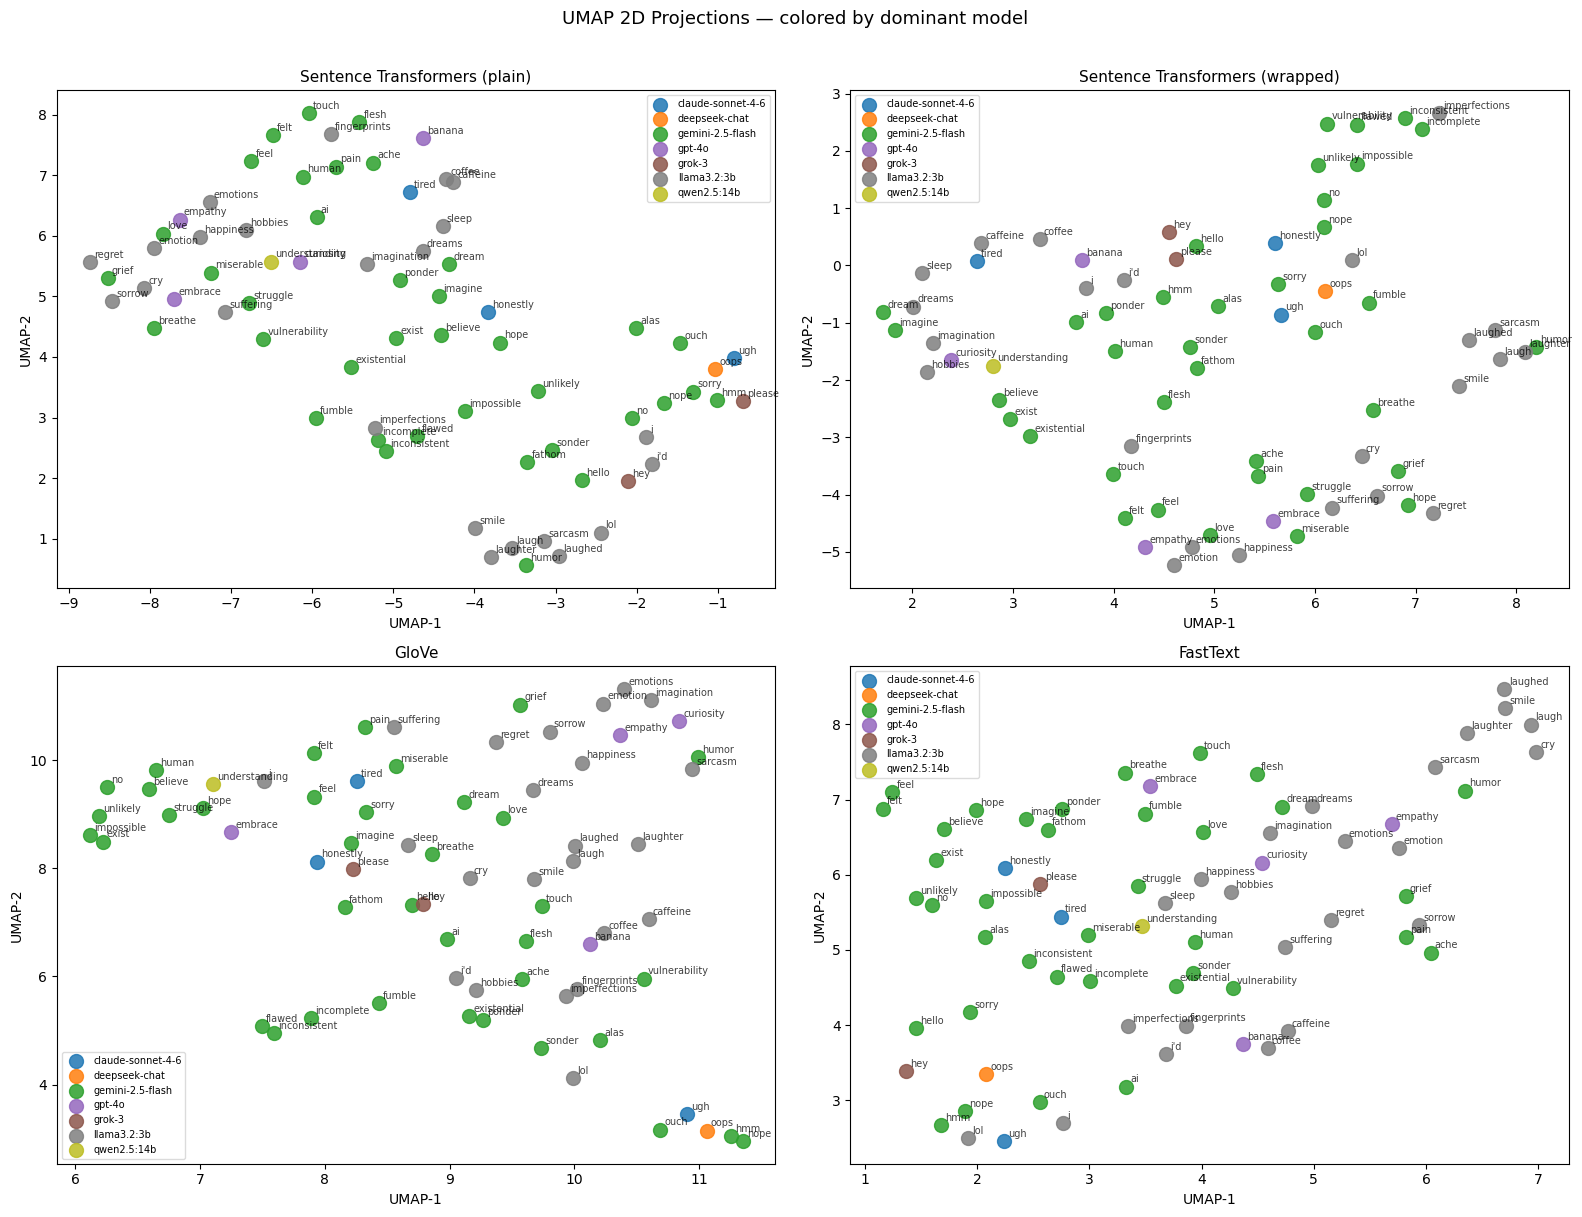

Saved data/figures/umap_preview.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

models_list = sorted(turing_df["model"].unique())
colors = {m: cm.tab10(i / len(models_list)) for i, m in enumerate(models_list)}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
titles = ["Sentence Transformers (plain)", "Sentence Transformers (wrapped)", "GloVe", "FastText"]
keys   = ["st_plain", "st_wrapped", "glove", "fasttext"]

for ax, key, title in zip(axes, keys, titles):
    df = umap_2d[key]
    for model, grp in df.groupby("model"):
        ax.scatter(grp["x"], grp["y"], label=model, color=colors[model], alpha=0.85, s=100, zorder=2)
        for _, row in grp.iterrows():
            ax.annotate(row["word"], (row["x"], row["y"]), fontsize=7, alpha=0.75,
                        xytext=(3, 3), textcoords="offset points")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7, loc="best", framealpha=0.7)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

plt.suptitle("UMAP 2D Projections — colored by dominant model", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/figures/umap_preview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved data/figures/umap_preview.png")

## Summary

### What we did and how it works

#### 1. Sentence Transformers (`all-MiniLM-L6-v2`)

A neural network (transformer) that reads a word or sentence and outputs a fixed-size vector of 384 numbers. These numbers encode semantic meaning — words with similar meaning end up with similar vectors. The model was pre-trained on millions of sentence pairs to make semantically related inputs produce similar outputs.

We ran it twice per word:
- **Plain**: feed the raw word (`"tired"`) — the model has little context to work with
- **Wrapped**: feed `"The word is: tired"` — the sentence frame activates more of the model's semantic knowledge, producing slightly richer embeddings

#### 2. GloVe (`glove-wiki-gigaword-100`)

A lookup table of 400,000 words, each mapped to a 100-number vector. The vectors were computed by analyzing how often words appear near each other in a large text corpus (Wikipedia + Gigaword). Words that appear in similar contexts (e.g. "tired" and "exhausted") end up with similar vectors. There is no neural network at query time — it is purely a dictionary lookup. Words not in the table (OOV) get a zero vector.

#### 3. FastText (`fasttext-wiki-news-subwords-300`)

Similar to GloVe but trained on Wikipedia news text, producing 300-number vectors. Also a lookup table when loaded via gensim — OOV words fall back to a zero vector. The subword capability (character n-gram inference) is only available when running the full FastText model, not the pre-computed KeyedVectors format used here.

---

#### 4. UMAP (Uniform Manifold Approximation and Projection)

Each word is now a point in high-dimensional space (384, 100, or 300 dimensions). UMAP compresses this down to 2 dimensions while trying to keep the neighborhood structure intact — if two words were close in high-dimensional space, they stay close in 2D.

It does this by:
1. Building a graph of each word's nearest neighbors in high-dimensional space
2. Constructing a similar graph in 2D
3. Minimizing the difference between the two graphs through optimization

Key parameters used:
- `n_neighbors=5` — each point looks at its 5 nearest neighbors to understand local structure; low values preserve tight local clusters
- `min_dist=0.3` — minimum allowed distance between points in 2D; higher values spread the layout out more
- `random_state=42` — fixes the random seed so results are reproducible

The result: each unique word becomes a (x, y) coordinate